# resolvendo a hamiltonina dependente do tempo

In [23]:
import torch as tc
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

from main.neuralnetwork import Rede,SIN

from main.function import expected, msa_loss, mse_loss, diagonal, Loss_EDO, plots_rho, expected_plot
from main.neuralnetwork import Rede, SIN
from tqdm import tqdm

In [ ]:
def data(lista_J, tfinal, N, device="cpu"):
    """
    Hamiltoniana dependente do tempo:
        H(t) = - B0 * sigma_y  -  B1 * cos(omega * t) * sigma_x
    lista_J = [B0, B1, omega]  (em unidades de frequência; multiplicadas por 2*pi no código)

    """
    # Operadores de Pauli
    sx = qt.sigmax()
    sy = qt.sigmay()
    sz = qt.sigmaz()

    # Non-driving Hamiltonian
    B0 = lista_J[0] * np.pi
    H0 = B0 * sx# TROCAR POR sz

    # Driving Hamiltonian
    B1 = lista_J[1] 
    w  = lista_J[2] * np.pi
    H1 = B1 * sx 
    args = {"w": w}

    # Forma compatível com sesolve/mesolve
    H_qutip = [H0, [H1, 'cos(w * t)']]

    # Collapse operators
    c_op_list = []
    # Operadores para medição <O>  ->  <σx>, <σy>, <σz>
    O_qobj = [sx, sy, sz]
    # Solução da equação de Schrödinger / mestre

    options = qt.Options(store_states=True)

    # Obtain Time Evolution

    tlist = np.linspace(0,tfinal, N)

    psi0 = qt.basis(2, 1)
    rho0 = qt.ket2dm(psi0)
    result = qt.mesolve(H_qutip, rho0, tlist,
                        c_ops=c_op_list, e_ops=O_qobj, args=args, options=options)

    # -----------------------
    # Construir H(t) em cada instante como matriz densa 2x2
    # -----------------------

    H_t_np = []

    for t in tlist:
        H_t = B0 * sz + B1 * np.cos(w * t) * sx
        H_t_np.append(H_t.full())

    H_t_np = np.array(H_t_np, dtype=np.complex64)   # shape (N, 2, 2)

    # Operadores de observável em forma de matriz

    O_op_np = np.array([op.full() for op in O_qobj], dtype=np.complex64)

    # Estados ao longo do tempo, achatados
    y_train_np = np.array(
        [result.states[i].full().flatten() for i in range(N)],
        dtype=np.complex64

    )
    # Valores médios <O>

    expect_np = np.array(result.expect)   # shape (n_ops, N)

    # -----------------------
    # Conversão para tensores do PyTorch
    # -----------------------
    H = tc.tensor(H_t_np, dtype=tc.complex64, device=device)      # (N, 2, 2)
    O_op = tc.tensor(O_op_np, device=device)                      # (3, 2, 2)
    y_train = tc.tensor(y_train_np, device=device)                # (N, 4)
    expect = tc.tensor(expect_np, device=device).transpose(0, 1)  # (N, 3)
    return y_train, expect, H, O_op

# y_train, expect, H, O_op = data([2, 0, 0], tfinal=1.0, N=100, device="cpu")

# tlist = np.linspace(0,1.0, 100)

# # resutlados 

# plt.plot(tlist, expect[:,0].numpy(), "r--", label="x")
# plt.plot(tlist, expect[:,1].numpy(), "g-", label="y")
# plt.plot(tlist, expect[:,2].numpy(), "b-.", label="z")

# plt.xlabel("Time")
# plt.legend()
# plt.show()

In [25]:
N_qubit    = 1
base_rho    = 2**N_qubit
neuro_      = [10,10]
funçao_de_ativa = [SIN()]
tfinal      = 1
N_pontos    = 200

real_net = Rede(neuronio   = neuro_,
                        input_     = 1, 
                        output_    = base_rho**2,
                        activation = funçao_de_ativa
                        ).to("cpu")

imag_net = Rede(neuronio   = neuro_,
                    input_      = 1,
                    output_     = base_rho**2,
                    activation  = funçao_de_ativa
                    ).to("cpu")

t_train = tc.linspace(
    0, tfinal, N_pontos, 
    dtype=tc.float32, 
    requires_grad=True
    ).reshape((-1, 1))

rho_data, valor_esperado_data, hamiltonina_data, Observavel_data = data(
    [1, 0, 0], 
    tfinal = tfinal,
    N = N_pontos, 
    device="cpu")

opt = tc.optim.Adam(
    list(real_net.parameters()) + list(imag_net.parameters()),
    lr = 0.01,
    betas = (0.9, 0.99),
    amsgrad = True,
)


100%|██████████| 10000/10000 [00:22<00:00, 443.98it/s]


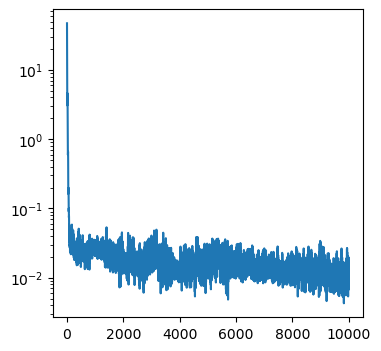

In [26]:

LOSS = []
for i in tqdm(range(10000)):
    ####### Forward pass #######
    y_r = real_net(t_train)
    y_i = imag_net(t_train)

    ####### Los edo #######
    loss_edo    = Loss_EDO(
                H_          = hamiltonina_data,
                rho_rvetor  = y_r,
                rho_ivetor  = y_i,
                tempo       = t_train,
                base_rho    = base_rho)

    ####### loss IC #######
    loss_ic     = mse_loss(y_r[0], rho_data[0].real) 
    loss_ic    += mse_loss(y_i[0], rho_data[0].imag)
    
    ####### Criando rho no farmato de matriz #######
    rho         = (y_r + 1j * y_i).reshape((N_pontos, base_rho, base_rho))

    ####### loss data(expected values) #######
    Tr_rho_O = expected(rho[0], Observavel_data).sum(dim=-1)
    loss_data = 0
    for i in range(len(Tr_rho_O)):
        loss_data += msa_loss(Tr_rho_O[i], valor_esperado_data[0, i]) 

    ####### Termo de normalizaçao #######
    Tr_rho      = diagonal(rho).sum(-1)
    loss_norma  = msa_loss(Tr_rho,1)
    
    ####### Calculate the loss #######
    loss        = loss_norma + loss_ic + loss_edo + loss_data

    ####### Backpropagation #######
    opt.zero_grad()
    loss.backward()
    opt.step()

    LOSS.append(loss.cpu().detach().numpy())
plt.subplots(figsize=(4, 4))
plt.plot(LOSS)
plt.yscale("log")
plt.show()

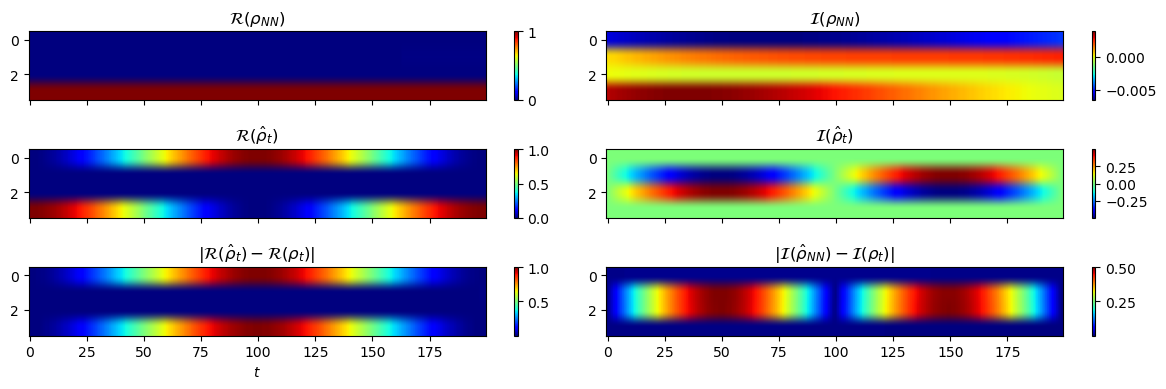

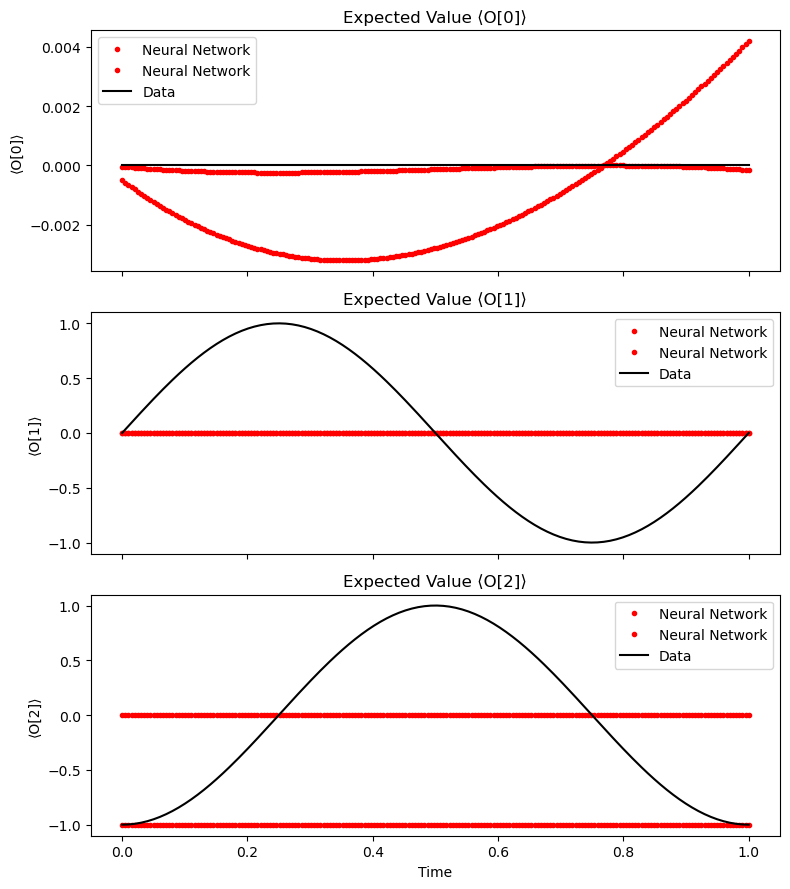

In [27]:
real_net.eval()
imag_net.eval()

####### inputs #######
time        = tc.linspace(0,tfinal,N_pontos).reshape((-1, 1))

####### Forward pass #######
y_r = real_net(time)
y_i = imag_net(time)

plots_rho(y_r, y_i, rho_data)

rho_1 = (y_r + 1j * y_i).reshape((N_pontos, base_rho, base_rho))
expected_plot(rho_ = rho_1,
                O_   = Observavel_data,
                expected_data = valor_esperado_data,
                time_ = time)